In [3]:
%load_ext autoreload
%autoreload 2
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))
import warnings
warnings.filterwarnings("ignore")

import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# dists_salsa = np.loadtxt(f'{rdir}anc_aug_dists/{tag_salsa}.txt')
# dists_contra = np.loadtxt(f'{rdir}anc_aug_dists/{tag_contra}.txt')
# dists_ae = np.loadtxt(f'{rdir}anc_aug_dists/{tag_ae}.txt')
# dists_fp = np.loadtxt(f'{rdir}anc_aug_dists/{tag_fp}.txt')

In [153]:
rdir = '/home/kat/Repos/SALSA/results/'

tag_salsa = '2022050220_salsa_2022041804_04_2000n_test_euc'
tag_contra = '2022050220_contra_2022041807_a03_2000n_test_euc'
tag_ae = '2022050220_ae_2022041809_a04_2000n_test_euc'
tag_fp = '2022050220_baseline_2000n_test_morgan_bitv_1024b_2r_eucnorm'

rows = []
for tag in [tag_salsa, tag_contra, tag_ae, tag_fp]:
    dists = np.loadtxt(f'{rdir}anc_aug_dists/{tag}.txt')
    version = tag.split('_')[1]
    for dist in dists:
        rows.append([version, dist])
        
df = pd.DataFrame(rows, columns=['method','Pairwise anc-aug distances'])

v_dict = {'salsa':'SALSA',
          'contra':'Contrast AE',
          'ae':'Vanilla AE',
          'baseline': 'Baseline (ECFP)'}

df['method'] = df['method'].map(v_dict)
df

,method,Pairwise anc-aug distances
0,SALSA,0.100449
1,SALSA,0.181409
2,SALSA,0.106483
3,SALSA,0.097523
4,SALSA,0.105389
...,...,...
39995,Baseline (ECFP),0.599727
39996,Baseline (ECFP),0.522668
39997,Baseline (ECFP),0.579568
39998,Baseline (ECFP),0.599727


In [155]:
(2000*5)*4

40000

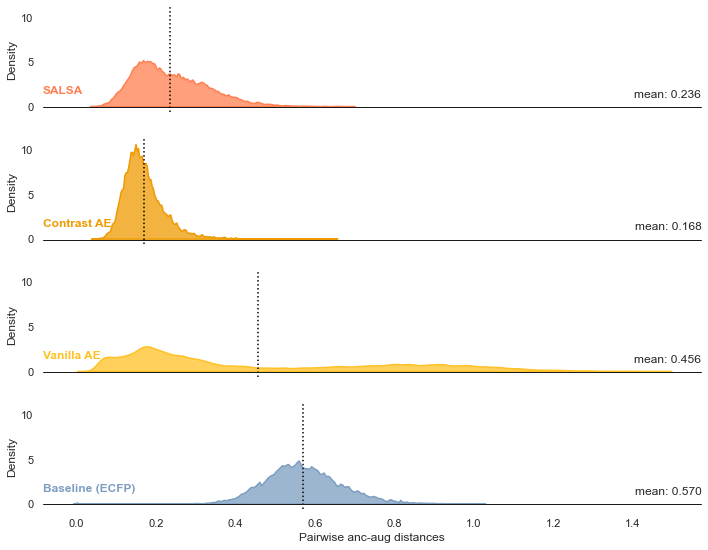

In [152]:
# source: https://stackoverflow.com/questions/59058641/...
# ... seaborn-facet-grid-adding-horizontal-mean-line-to-each-plt-plot-facet
def custom_vline(y, **kwargs):
    ym = y.mean()
    plt.axvline(ym, color="black", linestyle="dotted")
#     plt.annotate(f"mean = {y.mean():.3f}", xy=(ym+.1,.5), 
#                  xycoords=plt.gca().get_xaxis_transform(), ha="left")
    plt.annotate(f"mean: {y.mean():.3f}", xy=(1,1), 
                 xycoords=plt.gca().get_yaxis_transform(), ha="right")
    
# source: https://seaborn.pydata.org/examples/kde_ridgeplot.html
h = 2
asp = 5
# pal = sns.cubehelix_palette(4, rot=-.25, light=.7)
pal = sns.cubehelix_palette(n_colors=4, rot=-.25, dark=.3, light=.6)

pal = ['coral', '#EE9A00', '#FFC125', '#7D9EC0']

# Initialize the FacetGrid object
g = sns.FacetGrid(df, row="method", hue="method", aspect=asp, height=h, palette=pal)

# Draw the densities in a few steps
g.map(sns.kdeplot, "Pairwise anc-aug distances",
      clip_on=False, bw_adjust=.2,
      fill=True, alpha=.75, linewidth=1.5)
# This v is for drawing on the nice white outline in case of overlapping humps ... 
# g.map(sns.kdeplot, "Pairwise anc-aug distances", 
#       clip_on=False, bw_adjust=.2,
#       color="w", lw=2)

# g.map(lambda y, **kw: plt.axvline(y.mean(), color="k"), 'Pairwise anc-aug distances')
g.map(custom_vline, "Pairwise anc-aug distances")

# Passing color=None to refline() uses the hue mapping
g.refline(y=-.10, linewidth=1., linestyle="-", color='k', clip_on=False)
# g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)

# Define and use a simple function to label the plot in axes coordinates
def label(x, color, label):
    ax = plt.gca()
    ax.text(0, .2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)
g.map(label, "Pairwise anc-aug distances")

# Set the subplots to overlap
# g.figure.subplots_adjust(hspace=.1)

# Remove axes details that don't play well with overlap
g.set_titles("")
# g.set(ylabel="")
# g.set_yticklabels(labels=list(v_dict.values()))
g.despine(bottom=True, left=True)
display()

In [145]:
list(v_dict.values())

['SALSA', 'Contrast AE', 'Vanilla AE', 'Baseline (ECFP)']

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='ticks',font_scale=1.25,palette='muted')

if mtype=='salsa':
    t = 'SALSA (Graph-constrastive autoencoder)'
elif mtype=='contra':
    t = 'Contrastive encoder'
elif mtype=='ae':
    t = 'Vanilla autoencoder'

ylim = 1200
bns = 100

plt.figure(figsize=(15,3))
plt.title(t,fontsize=20)
plt.xlabel('Pairwise (anc-aug) Euclidean distance in latent manifold')

plt.ylim(0,ylim) #700

sns.histplot(anc_aug_dists, bins=bns, kde=True)

plt.savefig(f'{rdir}plot_figs/{tag}_{bns}bins_ylim{ylim}.png', bbox_inches='tight')
plt.show()